In [32]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [33]:
df = pd.read_csv("GEFCom2014_prepared.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["date", "hour"]).reset_index(drop=True)

In [34]:


df["hour"] = df["hour"].astype(int) % 24
df["day_of_week"] = df["day_of_week"].astype(int) % 7
df["month"] = df["month"].astype(int) - 1   # 0–11
df["is_weekend"] = df["is_weekend"].astype(int)

if "sum_zones" in df.columns:
    df = df.drop(columns=["sum_zones"])

In [35]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']

zone_cols = [
    "zone_residential",
    "zone_commercial",
    "zone_industrial"
]

print("Zones:", zone_cols)

Zones: ['zone_residential', 'zone_commercial', 'zone_industrial']


In [36]:
scaler = MinMaxScaler()

scale_cols = load_features + temp_features + zone_cols + ["load"]
df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [37]:
SEQ_LEN = 24

class MultiModalDataset(Dataset):
    def __init__(self, df):
        self.load_data = df[load_features].values.astype(np.float32)
        self.temp_data = df[temp_features].values.astype(np.float32)
        self.cal_data = df[calendar_features].values.astype(np.int64)
        self.targets = df[zone_cols + ["load"]].values.astype(np.float32)

    def __len__(self):
        return len(self.load_data) - SEQ_LEN

    def __getitem__(self, idx):
        Xl = self.load_data[idx:idx+SEQ_LEN]
        Xt = self.temp_data[idx:idx+SEQ_LEN]
        Xc = self.cal_data[idx:idx+SEQ_LEN]

        y = self.targets[idx+SEQ_LEN]

        return (
            torch.tensor(Xl),
            torch.tensor(Xt),
            torch.tensor(Xc),
            torch.tensor(y)
        )

In [38]:
dataset = MultiModalDataset(df)

train_size = int(0.8 * len(dataset))
train_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, len(dataset) - train_size]
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [39]:
class MultimodalMultiZoneModel(nn.Module):
    def __init__(self, num_zones):
        super().__init__()

        # Load encoder
        self.lstm = nn.LSTM(
            input_size=len(load_features),
            hidden_size=64,
            batch_first=True
        )

        # Temp encoder
        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        # Calendar embeddings
        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        fusion_size = 64 + 32 + (8 + 4 + 4 + 2)

        # 🔥 Multi-zone output
        self.fc = nn.Sequential(
            nn.Linear(fusion_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_zones + 1)
        )

    def forward(self, Xl, Xt, Xc):

        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        hour = self.hour_emb(Xc[:, -1, 0])
        day = self.day_emb(Xc[:, -1, 1])
        month = self.month_emb(Xc[:, -1, 2])
        weekend = self.weekend_emb(Xc[:, -1, 3])

        cal_out = torch.cat([hour, day, month, weekend], dim=1)

        fused = torch.cat([load_out, temp_out, cal_out], dim=1)

        return self.fc(fused)

In [40]:
model = MultimodalMultiZoneModel(num_zones=len(zone_cols)).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [41]:
EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for Xl, Xt, Xc, y in train_loader:
        Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(Xl, Xt, Xc)

        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.4f}")

Epoch 1 | Loss: 3.5399
Epoch 2 | Loss: 0.7023
Epoch 3 | Loss: 0.6017
Epoch 4 | Loss: 0.5580
Epoch 5 | Loss: 0.5403
Epoch 6 | Loss: 0.5268
Epoch 7 | Loss: 0.5205
Epoch 8 | Loss: 0.5123
Epoch 9 | Loss: 0.5112
Epoch 10 | Loss: 0.5056
Epoch 11 | Loss: 0.5013
Epoch 12 | Loss: 0.4976
Epoch 13 | Loss: 0.4949
Epoch 14 | Loss: 0.4951
Epoch 15 | Loss: 0.4906
Epoch 16 | Loss: 0.4912
Epoch 17 | Loss: 0.4878
Epoch 18 | Loss: 0.4879
Epoch 19 | Loss: 0.4865
Epoch 20 | Loss: 0.4838


In [46]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for Xl, Xt, Xc, y in test_loader:
        Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

        preds = model(Xl, Xt, Xc).cpu().numpy()

        all_preds.append(preds)
        all_true.append(y.numpy())

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true)

In [47]:
preds_full = all_preds
true_full = all_true

In [48]:
def bottom_up(preds):
    zones = preds[:, :-1]
    total = zones.sum(axis=1, keepdims=True)
    return np.concatenate([zones, total], axis=1)

def ols_reconciliation(preds):
    n = preds.shape[1] - 1
    S = np.vstack([np.eye(n), np.ones((1, n))])
    P = np.linalg.pinv(S.T @ S) @ S.T
    return preds @ P.T @ S.T

ind_preds = preds_full
bu_preds = bottom_up(preds_full)
ols_preds = ols_reconciliation(preds_full)

In [50]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

def coherence_error(preds):
    # Check if sum of zones (0,1,2) equals the total (3)
    return np.mean(np.abs(preds[:, :3].sum(axis=1) - preds[:, 3]))

# These will now run without ValueError
mae_ind, rmse_ind = evaluate(true_full, ind_preds)
mae_ols, rmse_ols = evaluate(true_full, ols_preds)
mae_bu, rmse_bu = evaluate(true_full, bu_preds)

coh_ind = coherence_error(ind_preds)
coh_ols = coherence_error(ols_preds)
coh_bu = coherence_error(bu_preds)

# Create results table
results = pd.DataFrame({
    "Model": ["Independent", "OLS", "Bottom-Up"],
    "MAE": [mae_ind, mae_ols, mae_bu],
    "RMSE": [rmse_ind, rmse_ols, rmse_bu],
    "Coherence Error": [coh_ind, coh_ols, coh_bu]
})

results

,Model,MAE,RMSE,Coherence Error
0,Independent,0.015209,0.022253,0.693315
1,OLS,0.173216,0.185381,0.000000
2,Bottom-Up,0.187038,0.368740,0.000000


In [51]:
results = pd.DataFrame({
    "Model": ["Independent", "OLS"],
    "MAE": [mae_ind, mae_ols],
    "RMSE": [rmse_ind, rmse_ols],
    "Coherence Error": [coh_ind, coh_ols]
})

results.to_csv("outputs/tables/rq2_coherence_results.csv", index=False)

results

,Model,MAE,RMSE,Coherence Error
0,Independent,0.015209,0.022253,0.693315
1,OLS,0.173216,0.185381,0.000000


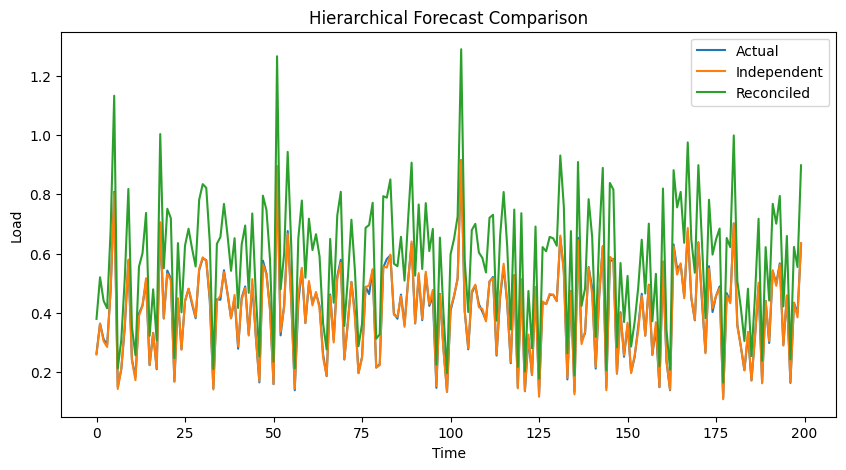

In [52]:
plt.figure(figsize=(10,5))

plt.plot(true_full[:200, -1], label="Actual")
plt.plot(ind_preds[:200, -1], label="Independent")
plt.plot(ols_preds[:200, -1], label="Reconciled")

plt.legend()
plt.title("Hierarchical Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Load")

plt.savefig("outputs/figures/rq2_hierarchical_comparison.pdf")
plt.show()

In [53]:
df.describe()

,date,hour,load,temp,day_of_week,month,day,is_weekend,lag_1,lag_24,...,zone_commercial,zone_industrial,temp_lag_1,temp_lag_24,temp_roll_mean_24,temp_roll_std_24,CDD,HDD,load_roll_mean_24,load_roll_std_24
count,78696,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,...,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000,78696.000000
mean,2010-07-06 00:00:00,11.500000,0.405004,0.570707,2.998170,5.536749,15.756023,0.285453,0.405003,0.404979,...,0.362483,0.375538,0.570707,0.570717,0.565311,0.327058,0.051858,0.229255,0.367780,0.384004
min,2006-01-09 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2008-04-07 00:00:00,5.750000,0.279838,0.443478,1.000000,3.000000,8.000000,0.000000,0.279838,0.279838,...,0.238255,0.259211,0.443478,0.443478,0.412080,0.202539,0.000000,0.024096,0.270370,0.298084
50%,2010-07-06 00:00:00,11.500000,0.424899,0.579710,3.000000,6.000000,16.000000,0.000000,0.424899,0.424899,...,0.336743,0.388074,0.579710,0.579710,0.579934,0.315118,0.000000,0.196787,0.350727,0.369281
75%,2012-10-03 00:00:00,17.250000,0.513396,0.704348,5.000000,9.000000,23.000000,1.000000,0.513396,0.513396,...,0.477258,0.477534,0.704348,0.704348,0.738752,0.438279,0.000000,0.385542,0.454932,0.448074
max,2014-12-31 00:00:00,23.000000,1.000000,1.000000,6.000000,11.000000,31.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,6.922231,0.156929,0.166851,2.000164,3.442014,8.792204,0.451633,0.156929,0.156921,...,0.164382,0.147944,0.166850,0.166836,0.196938,0.160130,0.129268,0.204432,0.139774,0.129717
